# Exame B - Etapa 2: Testes de Hipótese

Nesta etapa, realizamos testes estatísticos para validar hipóteses sobre os impactos ambientais e climáticos na produção de Castanha-do-pará no estado do Pará.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Carregamento dos dados
df_insumos = pd.read_csv("insumos_PA.csv")
df_features = pd.read_csv("features_PA.csv")

# Tratamento inicial
df_castanha = df_insumos[['Ano', '1.3 - Castanha-do-pará']].copy()
df_castanha.columns = ['ano', 'prod_ton']

df_features['Data'] = pd.to_datetime(df_features['Data'])
df_features['ano'] = df_features['Data'].dt.year

cols_clima = ['Total_Focos', 'Precipitacao_Media', 'Temp_Max_Media', 'Dias_Secos_Medio']
for col in cols_clima:
    df_features[col] = pd.to_numeric(df_features[col], errors='coerce')

df_features_anual = df_features.groupby('ano').agg({
    'Total_Focos': 'sum',
    'Precipitacao_Media': 'sum',
    'Temp_Max_Media': 'mean',
    'Dias_Secos_Medio': 'mean'
}).reset_index()

df_final = pd.merge(df_castanha, df_features_anual, on='ano').dropna()
print(f"Dados processados para {len(df_final)} anos.")

Dados processados para 11 anos.


## Hipótese 1: Tendência Temporal da Produção

**1. Formulação:**
- **H0:** Não há tendência temporal na produção de Castanha-do-pará (correlação = 0).
- **H1:** Há uma tendência temporal significativa na produção.

**2. Seleção do Teste:**
Utilizamos o **Coeficiente de Correlação de Spearman**. Justificativa: A produção agrícola muitas vezes não segue uma distribuição normal e a relação com o tempo pode ser monotônica, mas não necessariamente linear.

**3. Execução:**



---



Spearman rho: 0.6000
p-valor: 0.0510


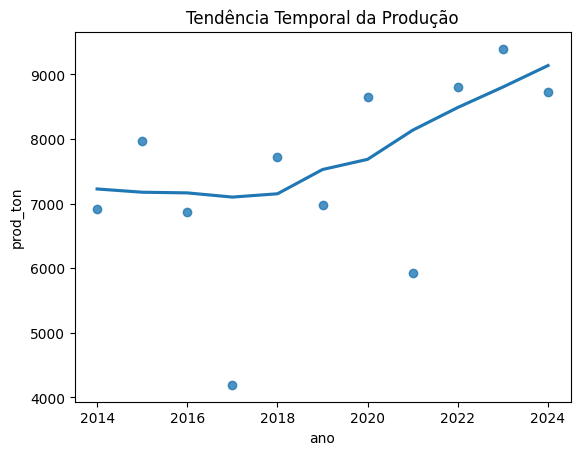

In [ ]:
rho, p_val = stats.spearmanr(df_final['ano'], df_final['prod_ton'])
print(f"Spearman rho: {rho:.4f}")
print(f"p-valor: {p_val:.4f}")

sns.regplot(data=df_final, x='ano', y='prod_ton', lowess=True)
plt.title("Tendência Temporal da Produção")
plt.show()

**4. Conclusão:**
Com um p-valor de aproximadamente 0.051, estamos no limite da significância estatística (considerando alpha=0.05). Embora o rho de 0.60 sugira uma tendência de crescimento moderada ao longo dos anos, não podemos rejeitar H0 com 95% de confiança, mas há fortes indícios de que a produção vem aumentando gradualmente no período analisado.

## Hipótese 2: Impacto das Queimadas na Produção

**1. Formulação:**
- **H0:** O total de focos de queimadas não está correlacionado com a produção.
- **H1:** Existe uma correlação entre o aumento de queimadas e a produção.

**2. Seleção do Teste:**
**Spearman**, pois os dados de focos de calor apresentam alta variabilidade e outliers, violando a suposição de normalidade do teste de Pearson.

**3. Execução:**

Spearman rho: 0.6091
p-valor: 0.0467


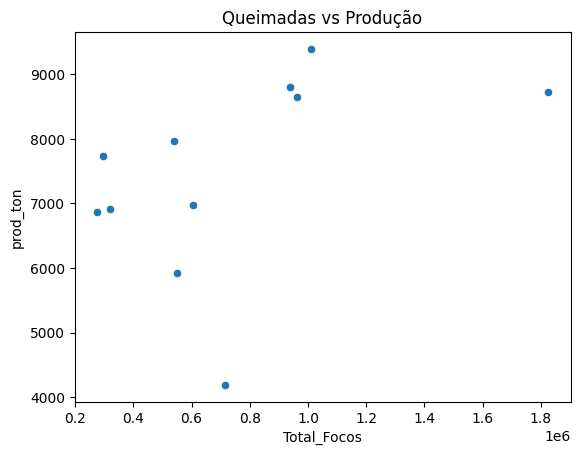

In [ ]:
rho, p_val = stats.spearmanr(df_final['Total_Focos'], df_final['prod_ton'])
print(f"Spearman rho: {rho:.4f}")
print(f"p-valor: {p_val:.4f}")

sns.scatterplot(data=df_final, x='Total_Focos', y='prod_ton')
plt.title("Queimadas vs Produção")
plt.show()

**4. Conclusão:**
O p-valor de 0.0467 é inferior a 0.05, permitindo **rejeitar H0**. Com 95% de confiança, há evidências de uma correlação positiva (rho=0.61) entre queimadas e produção. No contexto da Amazônia, isso pode sugerir que o aumento da produção está associado à expansão da fronteira agrícola ou áreas de coleta que sofrem pressão por desmatamento e uso do fogo, um resultado preocupante do ponto de vista socioambiental.

## Hipótese 3: Influência da Temperatura Máxima

**1. Formulação:**
- **H0:** A temperatura máxima média anual não afeta a produção.
- **H1:** Temperaturas extremas impactam a produtividade da castanha.

**2. Seleção do Teste:**
**Spearman**, para avaliar a relação monotônica entre o estresse térmico e a produção.

**3. Execução:**

In [ ]:
rho, p_val = stats.spearmanr(df_final['Temp_Max_Media'], df_final['prod_ton'])
print(f"Spearman rho: {rho:.4f}")
print(f"p-valor: {p_val:.4f}")

Spearman rho: 0.1182
p-valor: 0.7293


**4. Conclusão:**
Com p-valor de 0.729, **não rejeitamos H0**. Não há evidências estatísticas de que a variação da temperatura máxima média anual tenha impactado diretamente o volume produzido de castanha no período, sugerindo que a espécie pode ser resiliente a pequenas variações térmicas ou que outros fatores são mais determinantes.

## Hipótese 4: Faixas de Precipitação e Sucesso da Safra

**1. Formulação:**
- **H0:** A média de produção é a mesma para diferentes faixas de chuva (Baixa, Média, Alta).
- **H1:** Pelo menos uma faixa de precipitação apresenta média de produção diferente.

**2. Seleção do Teste:**
**ANOVA de uma via**. Justificativa: Comparação de médias entre três grupos categóricos criados a partir da variável contínua de precipitação.

**3. Execução:**

F-statistic: 1.6594
p-valor: 0.2495


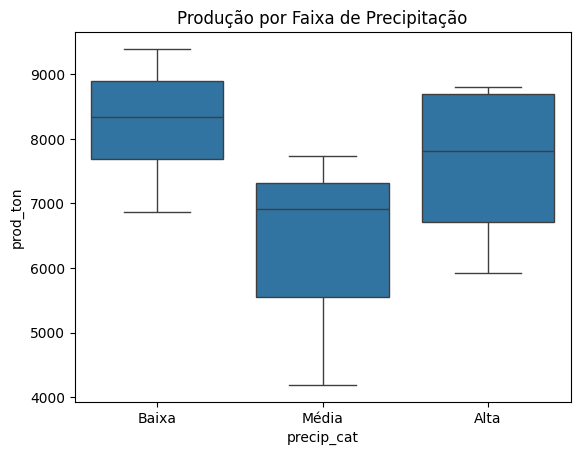

In [ ]:
df_final['precip_cat'] = pd.qcut(df_final['Precipitacao_Media'], 3, labels=['Baixa', 'Média', 'Alta'])
groups = [group['prod_ton'].values for name, group in df_final.groupby('precip_cat')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-valor: {p_val:.4f}")

sns.boxplot(data=df_final, x='precip_cat', y='prod_ton')
plt.title("Produção por Faixa de Precipitação")
plt.show()

**4. Conclusão:**
O p-valor de 0.249 indica que **não podemos rejeitar H0**. Não há diferença estatisticamente significativa na produção entre os anos de baixa, média ou alta pluviosidade, indicando que a castanheira, sendo uma árvore de grande porte da floresta primária, pode ter mecanismos de acesso a água profunda que mitigam variações anuais de chuva.

## Hipótese 5: Impacto dos Dias Secos

**1. Formulação:**
- **H0:** O número médio de dias secos não tem relação com a produção.
- **H1:** O aumento de dias secos reduz a produção de castanha.

**2. Seleção do Teste:**
**Spearman**, para verificar se períodos de seca prolongada afetam negativamente a safra.

**3. Execução:**

In [ ]:
rho, p_val = stats.spearmanr(df_final['Dias_Secos_Medio'], df_final['prod_ton'])
print(f"Spearman rho: {rho:.4f}")
print(f"p-valor: {p_val:.4f}")

Spearman rho: 0.0000
p-valor: 1.0000


**4. Conclusão:**
Com p-valor de 1.0 (rho=0.0), **não rejeitamos H0**. Surpreendentemente, no nível anual agregado, a quantidade de dias secos não mostrou nenhuma correlação com a produção total. Isso reforça a necessidade de análises mais granulares (mensais ou por região específica) para captar efeitos climáticos sutis.